# ARTI403 – Image Processing | Lab 2
## Digital Image Fundamentals

**Name:** Abdulrahman Alshaikh  
**ID:** 2240004223

**Environment:** Google Colab

## Install Required Libraries

In [1]:
!pip install -q opencv-python-headless Pillow matplotlib numpy scikit-image

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print(f"OpenCV version:  {cv2.__version__}")
print(f"NumPy version:   {np.__version__}")
print("All libraries imported successfully!")

OpenCV version:  5.0.0
NumPy version:   2.1.3
All libraries imported successfully!


## Prepare Lab Images

The manual's code paths point at `../images/...` (a shared `images` folder one level above the lab notebooks in the course repo). On Colab there's no such folder, so this cell builds a local `images/` folder with everything Lab 2 needs:

- `cameraman.tif` and `lena_gray_256.tif` — same as Lab 1.
- `A.png` and `B.png` — two overlapping binary shapes for the Sets and Logical Operations section (not provided as files, so they are generated here).

In [3]:
import os

os.makedirs('images', exist_ok=True)

from skimage import data as skdata
from skimage.io import imsave

cameraman = skdata.camera()
imsave('images/cameraman.tif', cameraman)
print(f"Saved cameraman.tif  — shape: {cameraman.shape}, dtype: {cameraman.dtype}")

!curl -L -s -o /tmp/lena_color.png \
  "https://upload.wikimedia.org/wikipedia/en/7/7d/Lenna_%28test_image%29.png"

lena_pil = Image.open('/tmp/lena_color.png').convert('L').resize((256, 256))
lena_pil.save('images/lena_gray_256.tif')
print(f"Saved lena_gray_256.tif  — size: {lena_pil.size}, mode: {lena_pil.mode}")

from PIL import ImageDraw

size = (300, 300)

canvas_a = Image.new('L', size, 0)
draw_a = ImageDraw.Draw(canvas_a)
draw_a.ellipse([40, 75, 220, 255], fill=255)
canvas_a.save('images/A.png')

canvas_b = Image.new('L', size, 0)
draw_b = ImageDraw.Draw(canvas_b)
draw_b.rectangle([100, 60, 260, 220], fill=255)
canvas_b.save('images/B.png')

print(f"Saved A.png  — size: {canvas_a.size}, mode: {canvas_a.mode}")
print(f"Saved B.png  — size: {canvas_b.size}, mode: {canvas_b.mode}")

for f in ['images/cameraman.tif', 'images/lena_gray_256.tif', 'images/A.png', 'images/B.png']:
    print(f"  ✓ {f}  ({os.path.getsize(f):,} bytes)")

Saved cameraman.tif  — shape: (512, 512), dtype: uint8
Saved lena_gray_256.tif  — size: (256, 256), mode: L
Saved A.png  — size: (300, 300), mode: L
Saved B.png  — size: (300, 300), mode: L
  ✓ images/cameraman.tif  (262,400 bytes)
  ✓ images/lena_gray_256.tif  (65,658 bytes)
  ✓ images/A.png  (1,110 bytes)
  ✓ images/B.png  (461 bytes)


## Part 1: Image Sampling and Quantization

### Step #1 & #2 — Import libraries and define functions

In [4]:
def sample_image(image, factor):
    """
    Downsamples the image by the given factor.

    Args:
        image (numpy array): Original image.
        factor (int): Factor by which to downsample.

    Returns:
        numpy array: Downsampled image.
    """
    height, width = image.shape[:2]
    sampled_image = cv2.resize(image, (width // factor, height // factor),
                                interpolation=cv2.INTER_NEAREST)
    return sampled_image


def quantize_image(image, levels):
    """
    Reduces the number of grayscale levels in the image.

    Args:
        image (numpy array): Original image.
        levels (int): Number of grayscale levels.

    Returns:
        numpy array: Quantized image.
    """
    quantized_image = np.floor(image / (256 // levels)) * (256 // levels)
    quantized_image = quantized_image.astype(np.uint8)
    return quantized_image


def plot_images(original, sampled, quantized):
    """
    Plots the original, sampled, and quantized images side by side.

    Args:
        original (numpy array): Original image.
        sampled (numpy array): Sampled image.
        quantized (numpy array): Quantized image.
    """
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(sampled, cmap='gray')
    plt.title('Sampled Image')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(quantized, cmap='gray')
    plt.title('Quantized Image')
    plt.axis('off')

    plt.show()

### Step #3 — Import the image and set the parameters

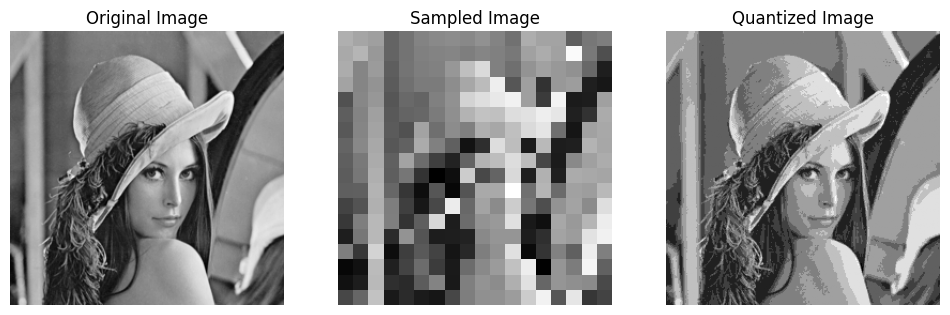

In [5]:
image_path = 'images/lena_gray_256.tif'
sampling_factor = 14
quantization_levels = 9

original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if original_image is None:
    print(f"Error: Unable to load image at {image_path}")

sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

plot_images(original_image, sampled_image, quantized_image)

### Task #1 — Change the sampling and quantization parameters and observe the effects

sampling_factor = 2, quantization_levels = 2


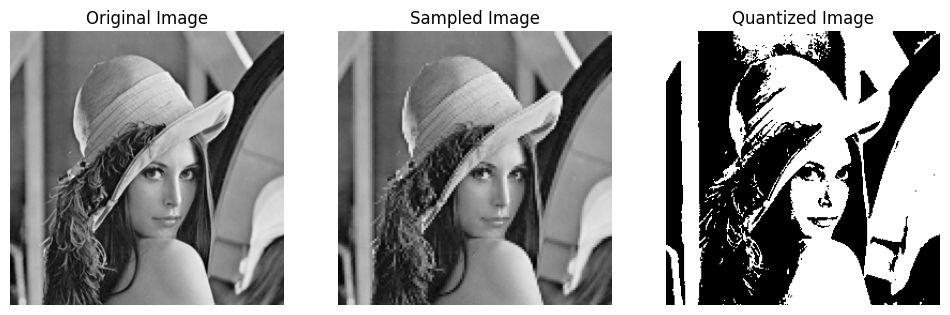

sampling_factor = 4, quantization_levels = 4


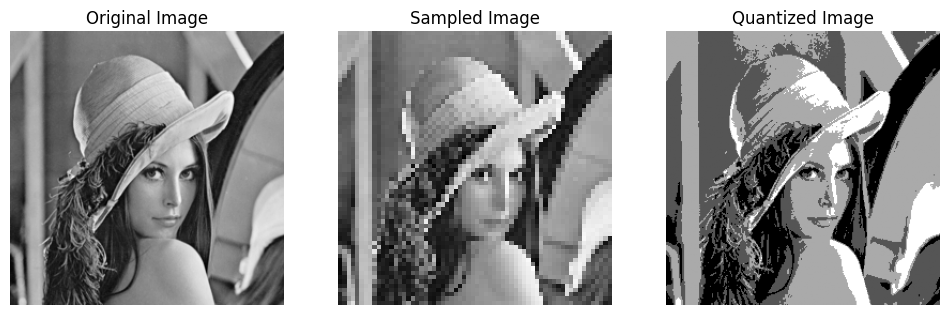

sampling_factor = 14, quantization_levels = 9


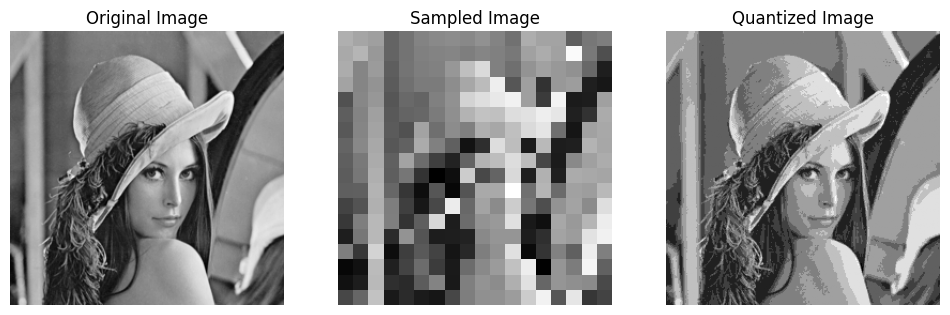

sampling_factor = 30, quantization_levels = 32


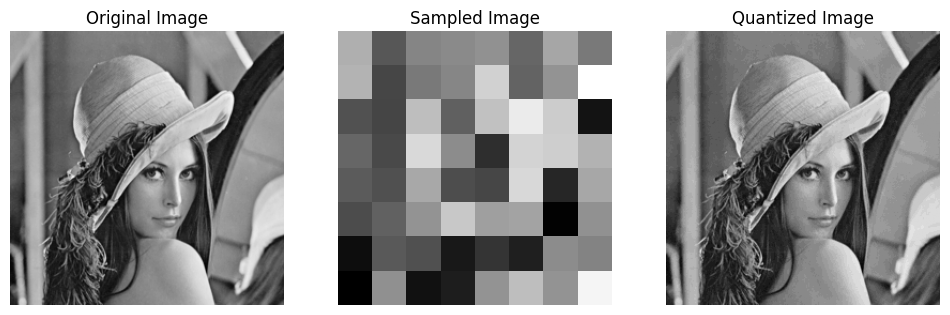

In [6]:
parameter_sets = [
    (2, 2),
    (4, 4),
    (14, 9),
    (30, 32),
]

for factor, levels in parameter_sets:
    print(f"sampling_factor = {factor}, quantization_levels = {levels}")
    sampled = sample_image(original_image, factor)
    quantized = quantize_image(original_image, levels)
    plot_images(original_image, sampled, quantized)

## Part 2: Arithmetic Operations

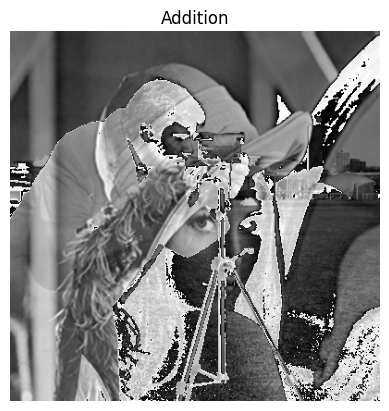

In [7]:
img1 = Image.open('images/lena_gray_256.tif')
img2 = Image.open('images/cameraman.tif')

resize = (400, 400)
img1 = img1.resize(resize, Image.Resampling.LANCZOS)
img2 = img2.resize(resize, Image.Resampling.LANCZOS)

im1arr = np.asarray(img1)
im2arr = np.asarray(img2)

addition = im1arr + im2arr
resultImage = Image.fromarray(addition)

plt.imshow(resultImage, cmap='gray')
plt.title('Addition')
plt.axis('off')
plt.show()

### Task #2.1 — Subtract two images and display the result

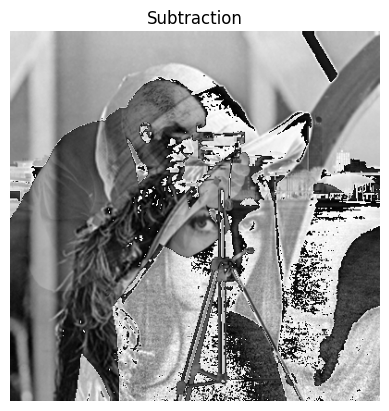

In [8]:
subtraction = im1arr - im2arr
resultImageSub = Image.fromarray(subtraction)

plt.imshow(resultImageSub, cmap='gray')
plt.title('Subtraction')
plt.axis('off')
plt.show()

### Task #2.2 — Add one image with a constant value of 175 and display it

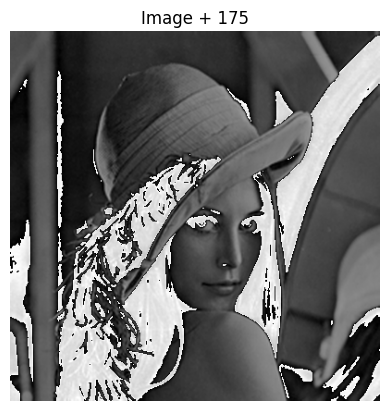

In [9]:
additionConstant = im1arr + 175
resultImageConst = Image.fromarray(additionConstant)

plt.imshow(resultImageConst, cmap='gray')
plt.title('Image + 175')
plt.axis('off')
plt.show()

## Part 3: Sets and Logical Operations

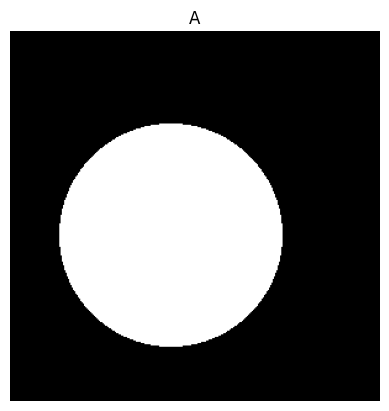

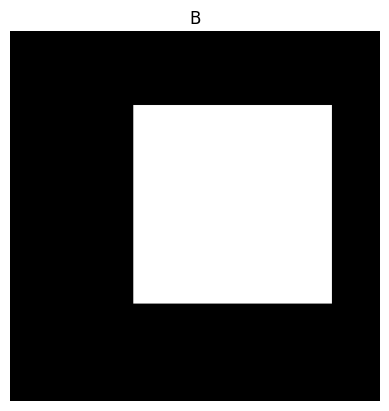

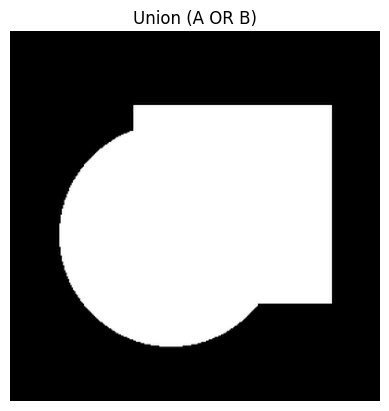

In [10]:
img3 = Image.open('images/A.png')
plt.imshow(img3, cmap='gray')
plt.title('A')
plt.axis('off')
plt.show()

img4 = Image.open('images/B.png')
plt.imshow(img4, cmap='gray')
plt.title('B')
plt.axis('off')
plt.show()

resize = (400, 400)
img3 = img3.resize(resize, Image.Resampling.LANCZOS)
img4 = img4.resize(resize, Image.Resampling.LANCZOS)

im3arr = np.asarray(img3)
im4arr = np.asarray(img4)

union = im4arr | im3arr
resultImage2 = Image.fromarray(union)

plt.imshow(resultImage2, cmap='gray')
plt.title('Union (A OR B)')
plt.axis('off')
plt.show()

### Task #2.3 — Apply the set difference operation on two Gray-Scale images

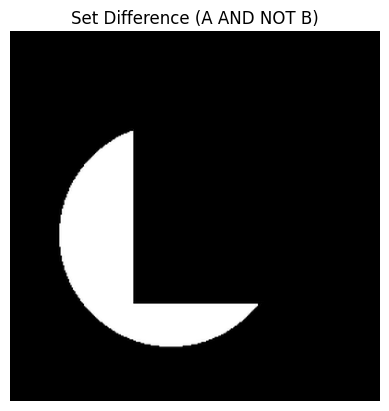

In [11]:
setDifference = im3arr & (~im4arr)
resultImage3 = Image.fromarray(setDifference)

plt.imshow(resultImage3, cmap='gray')
plt.title('Set Difference (A AND NOT B)')
plt.axis('off')
plt.show()

### Task #2.4 — Apply the symmetric difference operation on two Gray-Scale images

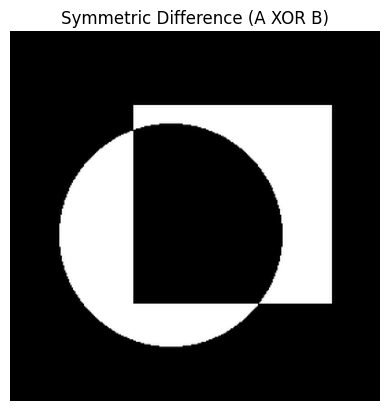

In [12]:
symmetricDifference = im3arr ^ im4arr
resultImage4 = Image.fromarray(symmetricDifference)

plt.imshow(resultImage4, cmap='gray')
plt.title('Symmetric Difference (A XOR B)')
plt.axis('off')
plt.show()

### Task #2.5 — Apply Intersection operations on two Gray-Scale images

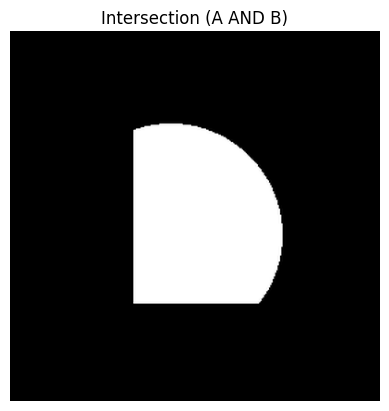

In [13]:
intersection = im3arr & im4arr
resultImage5 = Image.fromarray(intersection)

plt.imshow(resultImage5, cmap='gray')
plt.title('Intersection (A AND B)')
plt.axis('off')
plt.show()

## Assessment

All tasks above (Task #1 parameter sweep, Task #2.1–#2.5 array operations) are completed within this notebook.